In [1]:
import numpy as np
import sys,os
import scipy.special as sysp

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc
from time import time
import json

from cobaya.samplers.mcmc import plot_progress

from getdist.mcsamples import loadMCSamples
%matplotlib inline  
import getdist.plots as gdplt

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12 # 14
mpl.rcParams['legend.labelspacing'] = 0.2

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

***
# Quick Plots for Zel'dovich Smearing MCMC
***

In [3]:
Sample = 'Euclid-ELG' # '','DESI-LRG2','Euclid-ELG'

config_dict = {'DESI-LRG2': {'redshift':0.80,'Mmin':8e12,'phase':0,
                             'sample_root':'AbacusSummit/base_c000/'},
               'Euclid-ELG':{'redshift':1.10,'Mmin':1e12,'phase':9,
                             'sample_root':'AbacusSummit/base_c000/'},
               '':{'redshift':0.7,'Mmin':None,'sample_root':'SDBMC'}}

Redshift = config_dict[Sample]['redshift'] # 0.8 if Sample != '' else 0.7
M_min = config_dict[Sample]['Mmin']
Sample_Root = config_dict[Sample]['sample_root']

# Redshift = 0.8 if Sample != '' else 0.7
# Mmin_dict = {'DESI-LRG2':8e12,
#              # below are existing tests with 3x DESI volume
#              'DESI-LRG2-AP-x3':8e12 if Redshift > 0.5 else 1.25e13,
#              'DESI-LRG2-noAP-x3':8e12 if Redshift > 0.5 else 1.25e13}
# M_min = Mmin_dict[Sample]

Base_Dir = './'
Data_Dir = Base_Dir + 'data/'
Plots_Dir = Base_Dir + 'plots/'
Stats_Dir = Base_Dir + 'stats/'

File_Tail = 'lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift) if Sample != '' else 'sdbmc'

Parallel = True # True for mpi runs else False
Modify_Data = True
Include_Sig2Obs = True
VaryMC = True
Model_AP = True

Accuracy = 'mid' # 'low','mid','high'

L_Max = 3
File_Body = '_LMax{0:d}_'.format(L_Max) + File_Tail

chain_file = 'stats/chains/'
chain_file += 'varymc/' if VaryMC else 'nomc/'
chain_file += Sample_Root + Sample + '/mcmc' + File_Body
if Include_Sig2Obs:
    chain_file += '_inclSig2obs'
if not Modify_Data:
    chain_file += '_unmod'
if Accuracy != 'mid':
    chain_file += '_'+Accuracy+'acc'
if Parallel:
    chain_file += '_mpi'
    NProc = 6 # should match ZelSmear_MCMC_mpi.ipynb
else:
    NProc = 1
if L_Max < 3:
    chain_file += '_LMax{0:d}'.format(L_Max)

Derived_List = ['f','peak','LP','ZC']
Derived_Latex = ['f','r_{\\rm peak}','r_{\\rm LP}','r_{\\rm ZC}']

# Use_Basis = np.array([0,1,3,5,7,8]) 
Use_Basis = np.arange(9)
N_Basis = len(Use_Basis)
dim = N_Basis + 7
if L_Max > 1:
    dim += 1
    if L_Max == 3:
        dim += 1
if Include_Sig2Obs:
    dim += 1
if Model_AP:
    dim += 2
if not VaryMC:
    dim -= 1 # don't sample AMC
if Modify_Data & (L_Max > 1):
        dim -= 1 # don't sample qbar2 (for L_Max==2) or qbar4 (for L_Max==3)

Scales_File = Data_Dir + Sample_Root + Sample + '/xi' + File_Body + '_scales.txt'
Scales = np.loadtxt(Scales_File)

Ndata = Scales.size*L_Max
if Modify_Data & (L_Max > 1):
    Ndata -= 1
    if L_Max == 3:
        Ndata -= 1
if Include_Sig2Obs:
    Ndata += L_Max
dof = Ndata - dim
print('dof =',dof,'; dim =',dim)
print('chain file:',chain_file)

dof = 71 ; dim = 20
chain file: stats/chains/varymc/AbacusSummit/base_c000/Euclid-ELG/mcmc_LMax3_lgMmin12.00_z1.100_inclSig2obs_mpi


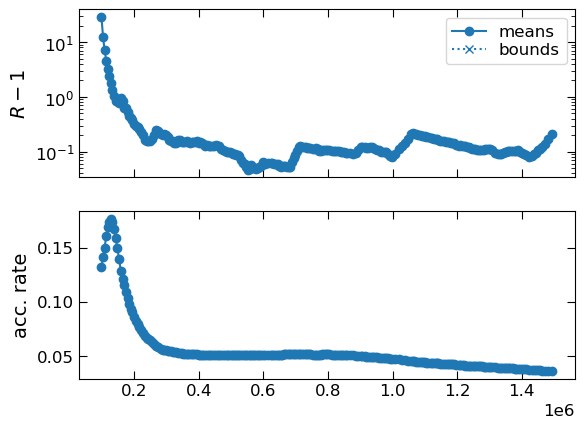

In [6]:
plot_progress(chain_file)
plt.show()

['beta', 'sigv', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B1st', 'Bvst', 'sigma', 'AMC', 'qbar2', 'fv', 'Daiso', 'DaAP', 'f', 'peak', 'LP', 'ZC', 'chi2']
1043307 869013 [ 4.3289158e-01  7.4542192e+00  2.2344913e-04  1.3314086e-03
 -3.6316709e-03  6.8012218e-03  6.9932578e-04  1.1810594e-02
 -8.6780871e-03  4.6304476e-03  2.5381232e-03  1.7801375e+00
  3.4138307e+00 -1.3550839e+01  1.0792525e+01  3.1049721e-02
  6.8198302e-01  4.4535783e-02  1.2752802e-01 -8.6983176e-02
  7.7060652e-01  1.0443306e+02  9.6720798e+01  1.4496541e+02
  7.2848300e+01] 1.026032394366197 0.4605470589166489
MAP: [ 4.7319936e-01  3.2555987e+00  2.6392988e-03 -7.5357540e-03
 -3.7389294e-03  9.8928381e-03  7.5917176e-03  6.7327370e-03
 -5.9766982e-03  4.0510324e-03  1.0502926e-02  1.7680612e+00
 -5.5642499e+00 -7.0506668e-01  1.0128083e+01 -2.9822682e-03
  4.0831160e-02  2.5939887e-01  5.1764432e-02 -1.3930334e-02
  8.3664544e-01  1.0043271e+02  9.3017917e+01  1.1840163e+02
  7.9741431e

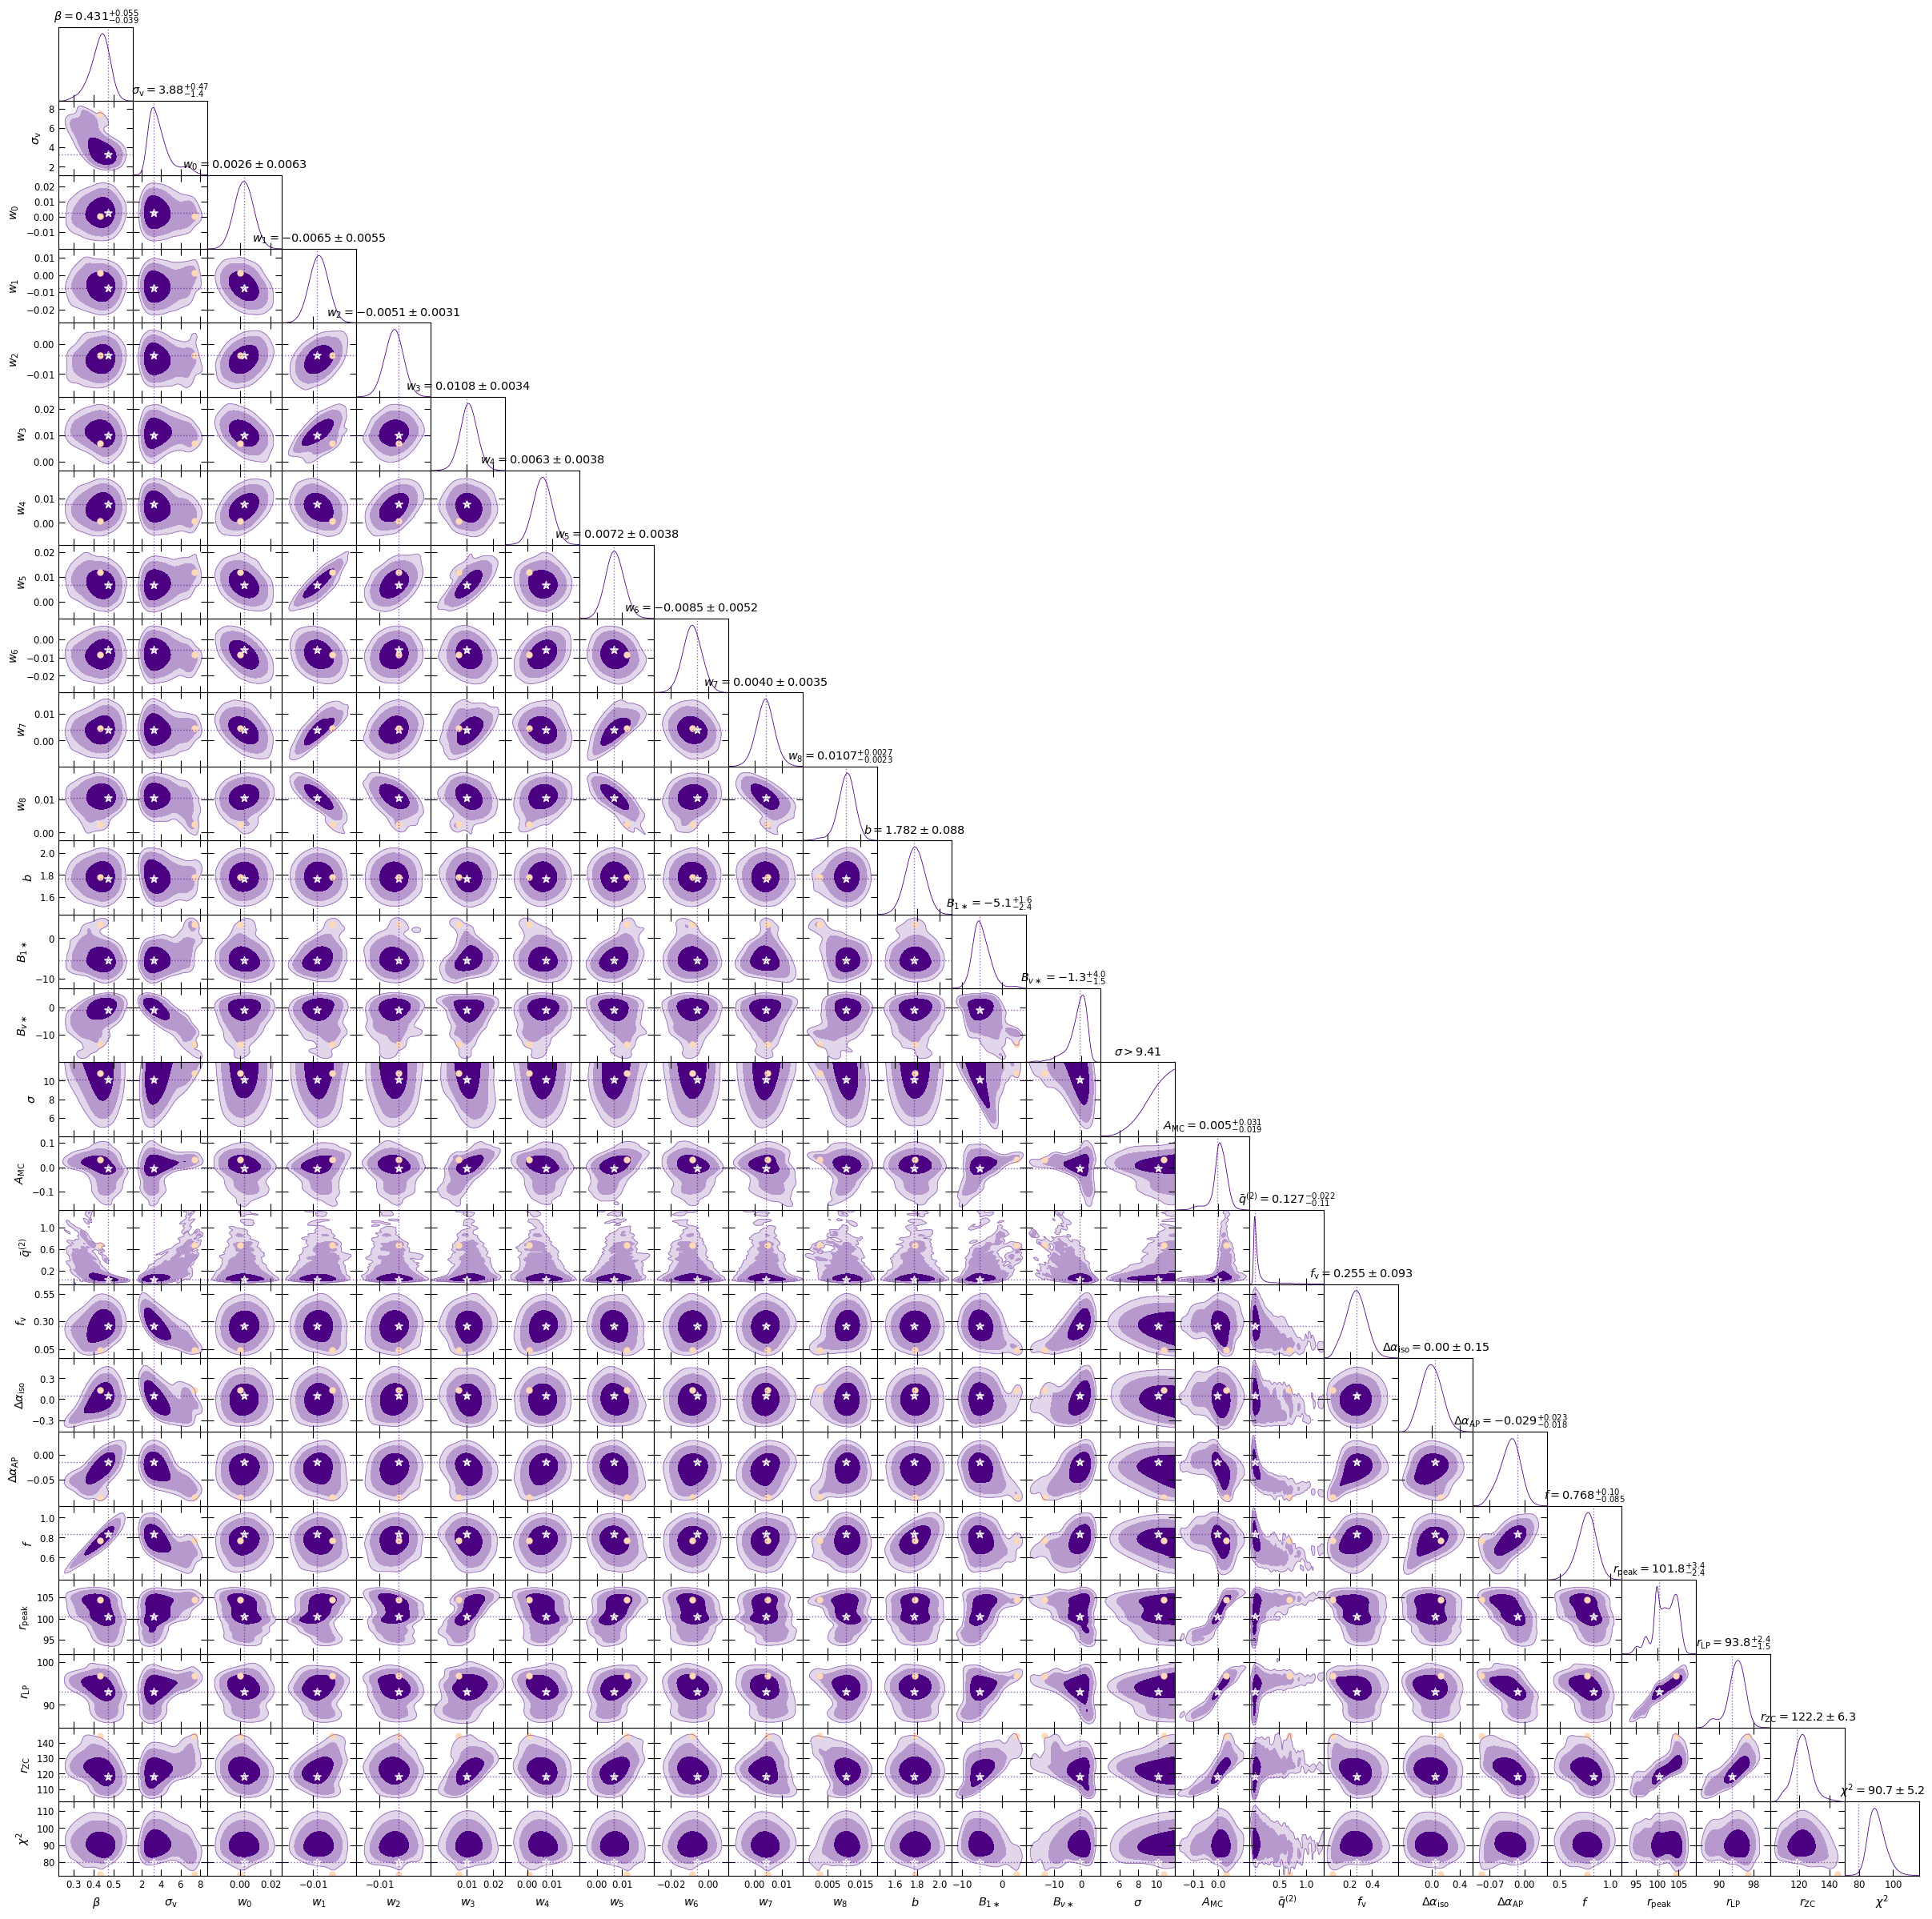

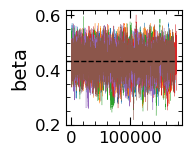

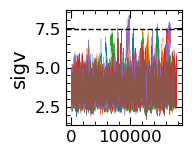

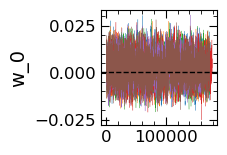

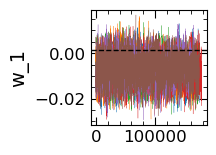

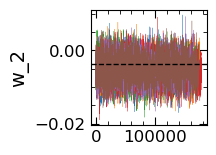

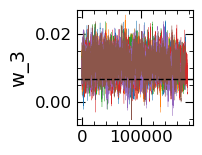

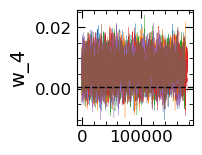

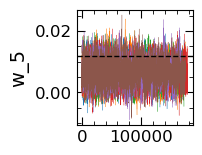

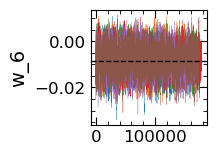

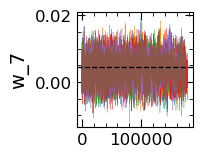

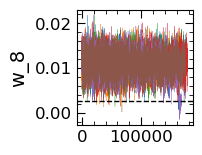

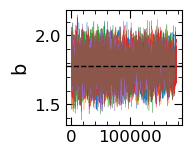

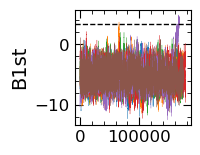

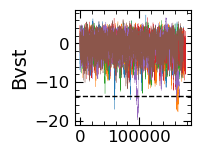

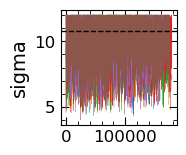

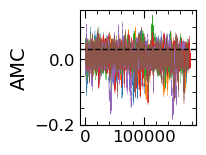

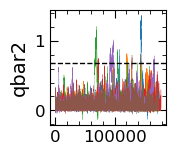

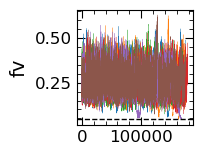

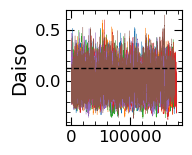

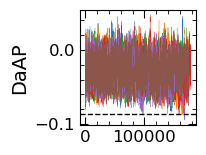

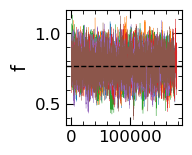

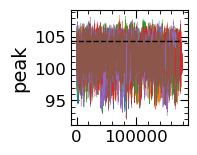

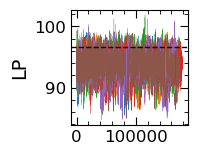

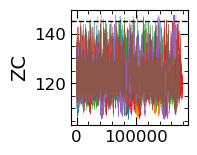

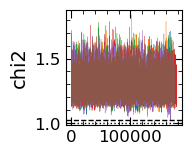

In [5]:
Show_Plots = True

gd_sample = loadMCSamples(os.path.abspath(chain_file),settings={'ignore_rows':0.3})
W_Names = ['w_{0:d}'.format(m) for m in Use_Basis] 
plot_param_list = ['beta','sigv']
plot_param_list.extend(W_Names)
plot_param_list += ['b','B1st','Bvst','sigma']
if VaryMC:
    plot_param_list += ['AMC']
if L_Max > 1:
    if (not Modify_Data) | (L_Max == 3):
        # note L_Max==3 not 2
        plot_param_list += ['qbar2']
    if (L_Max == 3) & (not Modify_Data):
        plot_param_list += ['qbar4']
if Include_Sig2Obs:
    plot_param_list += ['fv']
if Model_AP:
    plot_param_list += ['Daiso','DaAP']
plot_param_list += Derived_List
plot_param_list += ['chi2']
print(plot_param_list)

Subplot_Size = 1.2

ibest = gd_sample.samples.T[-2].argmin()
mcmc_best = gd_sample.samples[ibest]
chi2_min = mcmc_best[-1]
i_last = 3 #if SDBMC else 1
mcmc_best = mcmc_best[:-i_last].copy()
mcmc_best[-1] = chi2_min
pval = sysp.gammainc(chi2_min/2,dof/2)
print(gd_sample.samples.shape[0],ibest,mcmc_best,chi2_min/dof,pval)

offset = 2
par_show = np.arange(len(plot_param_list)) + offset
par_show[-1] = -2

sample_for_MAP = np.loadtxt(os.path.abspath(chain_file)+'.'+str(1)+'.txt')
sample_for_MAP = sample_for_MAP[int(0.3*sample_for_MAP.shape[0]):]
for c in range(1,NProc):
    sample = np.loadtxt(os.path.abspath(chain_file)+'.'+str(c+1)+'.txt')
    sample = sample[int(0.3*sample.shape[0]):]
    sample_for_MAP = np.concatenate((sample_for_MAP,sample),axis=0)
iMAP = sample_for_MAP.T[1].argmin()
mcmc_MAP = sample_for_MAP[iMAP][par_show]
print('MAP:',mcmc_MAP)

if Show_Plots:
    gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
    gdplot.settings.num_plot_contours = 3
    gdplot.settings.axes_fontsize = FS3
    gdplot.settings.axes_labelsize = FS2
    gdplot.settings.title_limit_fontsize = FS2
    gdplot.settings.title_limit = 1
    
    gdplot.triangle_plot([gd_sample], plot_param_list,
                         filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                         markers=mcmc_MAP,#mcmc_best,
                         marker_args={'c': 'indigo','ls': ':','lw': 1.0,'alpha': 0.6})
    
    for par_y in range(par_show.size):
        str_y = plot_param_list[par_y]
        for par_x in range(par_y):
            str_x = plot_param_list[par_x]
            ax = gdplot.subplots[par_y,par_x]
            ax.scatter([mcmc_MAP[par_x]],[mcmc_MAP[par_y]],
                       marker='*',s=50,c='white')
            ax.scatter([mcmc_best[par_x]],[mcmc_best[par_y]],
                       marker='o',s=25,c='peachpuff')
            
            
    show_chain = []
    for c in range(NProc):
        sample = np.loadtxt(os.path.abspath(chain_file)+'.'+str(c+1)+'.txt')
        sample = sample[int(0.3*sample.shape[0]):]
        sample = sample.T
        sample[-2] /= dof
        show_chain.append(sample[par_show])
    
    for p in range(par_show.size): 
        plt.figure(figsize=(1.5,1.5))
        plt.ylabel(plot_param_list[p])
        for c in range(NProc):
            plt.plot(show_chain[c][p],'-',lw=0.2)
        mark = mcmc_best[p]/dof if p == par_show.size-1 else mcmc_best[p]
        plt.axhline(mark,c='k',ls='--',lw=1)
        if p == par_show.size - 1:
            plt.axhline(1,c='k',ls=':',lw=1)
        plt.minorticks_on()
        plt.show()